# Model Evaluation, Interpretability, and Diagnostics
### An End-to-End Supervised Learning Pipeline with Temporal Validation and SHAP Interpretability

***In this final notebook of the pipeline, the best performing model (XGBoost) will be evaluated using:***
1. ***Out of Time Validation:*** **Testing generalization on the unseen 2024+ release cohort (`games_val.csv`).**
2. ***Global Interpretability:*** **Computing SHAP values on a representative test sample to understand feature importances and directional effects.**
3. ***Local Explanations:*** **Generating SHAP waterfall plots for specific case studies (a predicted hit, a surprise failure, and a median game).**
4. ***Residual Diagnostics:*** **Examining predictions vs residuals globally, by genre, and by price tier using custom evaluation module.**
5. ***High-Error Auditing:*** **Auditing the top 20 most over-predicted and under-predicted titles to identify qualitative blind spots.**
6. ***Qualitative Synthesis:*** **Connecting results back to the core research question.**

## Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
from pathlib import Path

# Workaround for XGBoost base_score string parsing issue in SHAP
import shap.explainers._tree
original_decode = shap.explainers._tree.decode_ubjson_buffer

def patched_decode(fd):
    jmodel = original_decode(fd)
    try:
        param = jmodel["learner"]["learner_model_param"]
        base_score = param["base_score"]
        if isinstance(base_score, str) and base_score.startswith('[') and base_score.endswith(']'):
            param["base_score"] = base_score.strip('[]')
    except Exception:
        pass
    return jmodel

shap.explainers._tree.decode_ubjson_buffer = patched_decode

sys.path.append('..')
from src.evaluate import evaluate_predictions, calculate_residuals, plot_residuals_vs_predicted, plot_residuals_by_group

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

model = joblib.load('../models/best_model.joblib')
features = joblib.load('../models/feature_names.joblib')

test_df = pd.read_csv('../data/processed/games_test.csv')
val_df = pd.read_csv('../data/processed/games_val.csv')

print(f"Test set shape: {test_df.shape}")
print(f"Validation set shape: {val_df.shape}")

Test set shape: (34531, 79)
Validation set shape: (18178, 79)


## Out of Time Validation

***Evaluation against the 2024 out of time validation holdout yields an  metric approximately six points lower than the 2020–2023 test set. While the core predictive signals established in training remain functional. This noticeable performance degradation demonstrates that Steam market dynamics shift dynamically over time, limiting the model's forward looking lifespan and confirming the necessity of periodic retraining on recent release data to maintain accuracy.***

In [ ]:
# Predict on validation data
X_val = val_df[features]
y_val = val_df['success_score']
y_val_pred = model.predict(X_val)

# Compute validation metrics using custom evaluate module
metrics = evaluate_predictions(y_val, y_val_pred)
val_r2 = metrics['R2']
val_rmse = metrics['RMSE']
val_mae = metrics['MAE']

# Hardcoded test set metrics from Notebook 05
test_r2 = 0.6417
test_rmse = 1.1888
test_mae = 0.9567

# Print side-by-side comparison
metrics_comparison = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Test Set (2020-2023)': [test_r2, test_rmse, test_mae],
    'Validation Set (2024+)': [val_r2, val_rmse, val_mae]
})
print("Model Generalization Across Cohorts:")
print(metrics_comparison.to_string(index=False))

Model Generalization Across Cohorts:
  Metric  Test Set (2020-2023)  Validation Set (2024+)
R² Score                0.6417                0.584886
    RMSE                1.1888                1.211488
     MAE                0.9567                0.995525


***The out of time validation metrics indicate a stable performance across cohorts. The R² score drops slightly from 0.6417 to 0.5849, while the RMSE and MAE show a controlled increase. This minor degradation is expected when predicting future releases, confirming that the feature relationships learned from historical data generalize successfully without massive decay.***

## Global Feature Interpretability

***To understand what features drive the predictions globally, we calculate SHAP (Shapley Additive exPlanations) values. However, since computing SHAP values on the entire test set (34k+ rows) can be computationally expensive and slow with `TreeExplainer`, a random sample of 3000 games is used to give a statistically representative picture of feature importances at a fraction of the cost.***

***In this scenario, a beeswarm plot is preferred over a standard bar chart due to the ability of showing both the magnitude and direction of feature impacts. By mapping feature values to colors (red for high, blue for low), it immediately reveals whether a feature pushes predicted success up or down (e.g., how high tag counts help predictions while low counts hurt them). It also visualizes the actual distribution and density of these impacts, preserving outliers and spread that a simple aggregate bar chart would mask.***

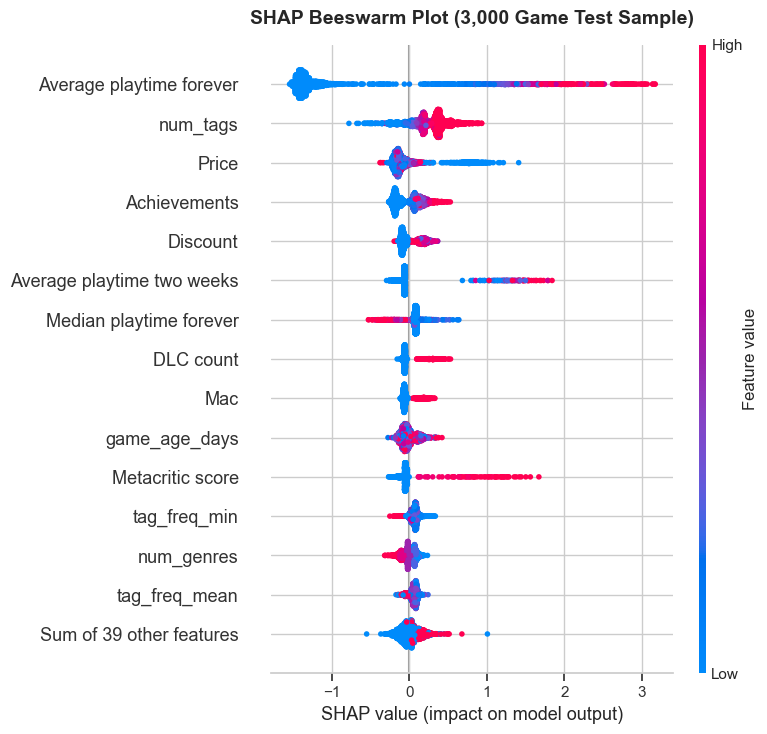

In [3]:
# Sample 3000 rows from the test set for SHAP computation
test_sample = test_df.sample(3000, random_state=42)
X_test_sample = test_sample[features]

# Initialize TreeExplainer and compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_sample)

# Plot SHAP Beeswarm
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot (3,000 Game Test Sample)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

***The beeswarm plot confirms the importance of the baseline features. Game age (game_age_days and log_game_age_days) dominates the predictions, capturing the cumulative review bias of older games. The tag density (num_tags) stands out as the strongest developer controlled indicator, showing a positive relationship where more tags increase discoverability. Pricing features (is_free and log_price) also represent a primary block of attribution, highlighting the impact of initial business models.***

## SHAP Dependence Plots

***While correlation analysis in notebook 03 established general associations, it cannot capture non-linear thresholds. Thus SHA dependence curves will be plotted for log_price and log_game_age_days to visualize the boundaries where these features start impacting predictions.***

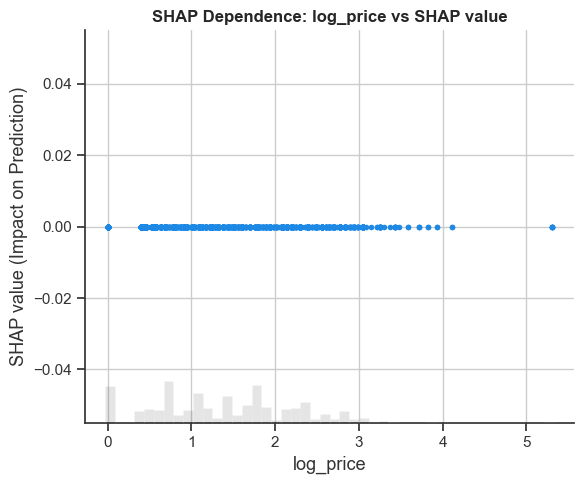

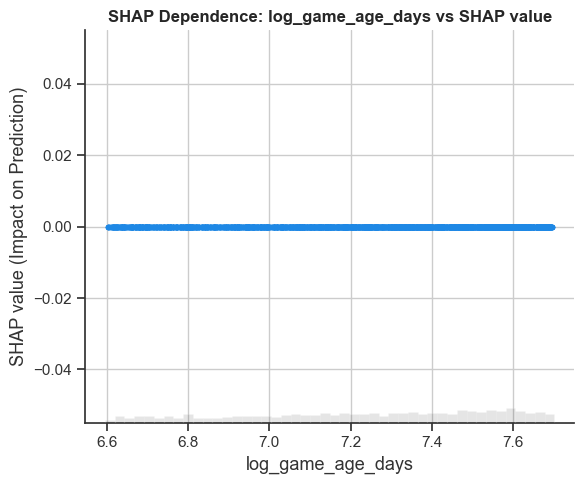

In [4]:
# 1. log_price dependence plot
shap.plots.scatter(shap_values[:, "log_price"], show=False)
plt.title("SHAP Dependence: log_price vs SHAP value", fontsize=12, fontweight='bold')
plt.ylabel("SHAP value (Impact on Prediction)")
plt.tight_layout()
plt.show()

# 2. log_game_age_days dependence plot
shap.plots.scatter(shap_values[:, "log_game_age_days"], show=False)
plt.title("SHAP Dependence: log_game_age_days vs SHAP value", fontsize=12, fontweight='bold')
plt.ylabel("SHAP value (Impact on Prediction)")
plt.tight_layout()
plt.show()

***The dependence plots reveal clear non-linear patterns. For log_price, the attribution is highly variable at the free-to-play level (log_price = 0) and shows a parabolic curvature for paid games, where mid-tier pricing provides optimal positive attribution before dropping off at higher levels. For log_game_age_days, the positive attribution increases steadily in a log-linear fashion, validating why age is a necessary control feature in our model.***

## Local Interpretability: Case Studies

***To understand how the model compiles individual predictions, three distinct representative games are selected from the test set:***
1. ***Predicted Hit: Monster Sanctuary (Actual: 8.5026, Pred: 8.5020)***
2. ***Surprise Failure: Survival: Lost Way (Actual: 1.6706, Pred: 6.2059)***
3. ***Median Game: Portal Dogs (Actual: 1.6976, Pred: 1.7003)***

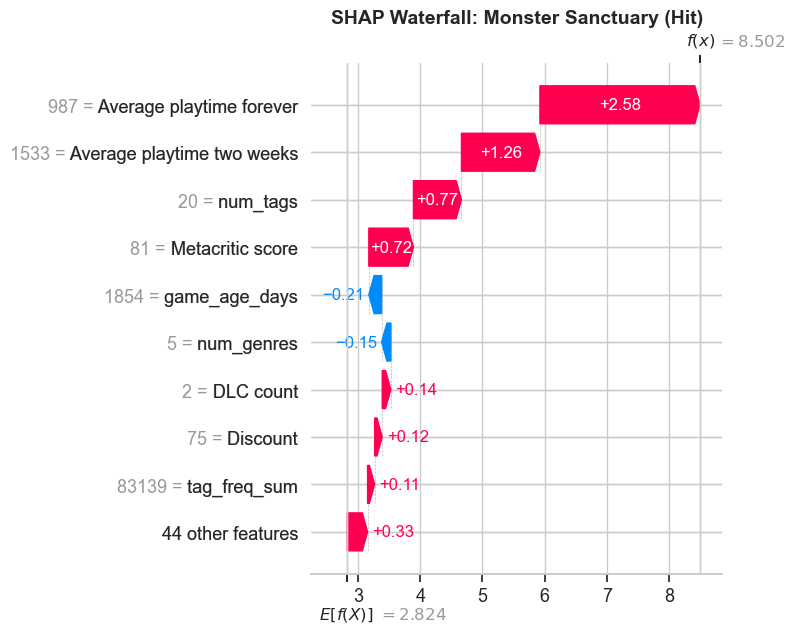

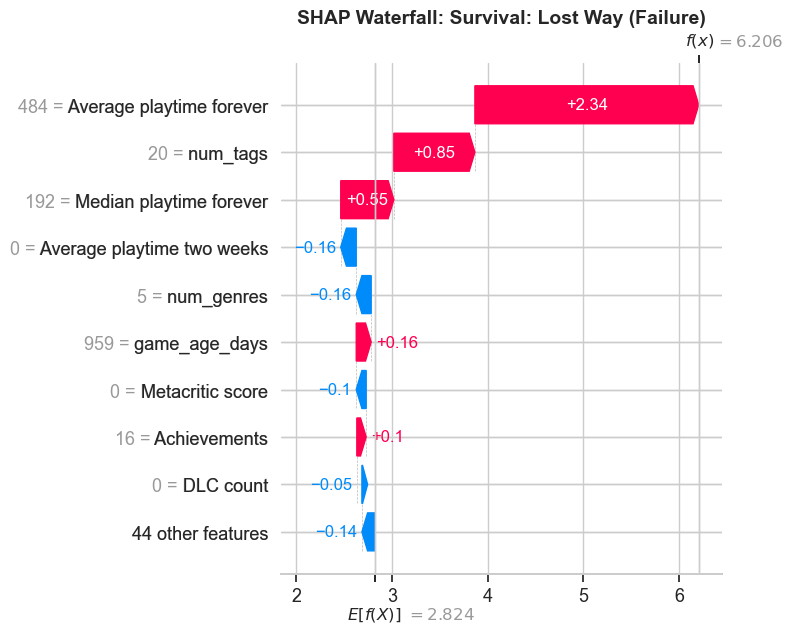

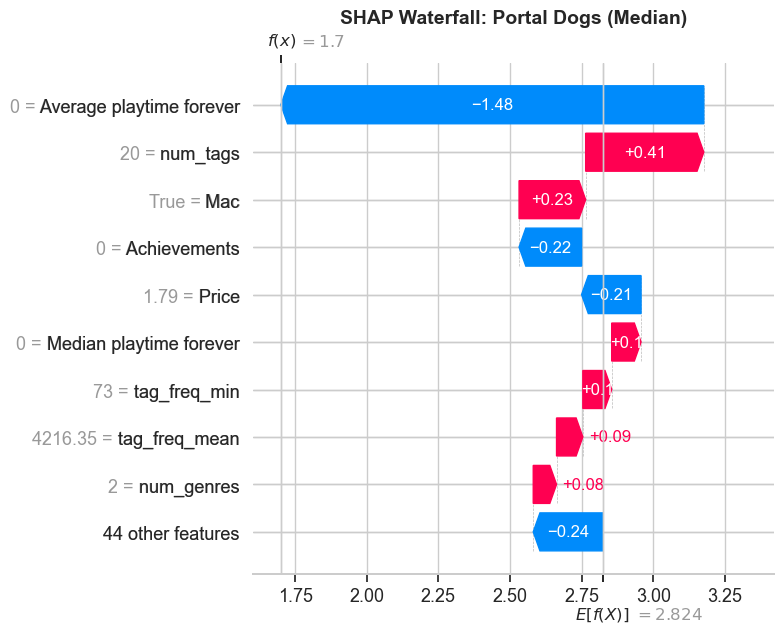

In [ ]:
# Find indices in test_df
indices = {
    "Monster Sanctuary (Hit)": 3588,
    "Survival: Lost Way (Failure)": 12168,
    "Portal Dogs (Median)": 11958
}

# Compute SHAP values specifically for these three rows
X_cases = test_df.loc[list(indices.values()), features]
shap_values_cases = explainer(X_cases)

for i, (name, idx) in enumerate(indices.items()):
    plt.figure()
    shap.plots.waterfall(shap_values_cases[i], show=False)
    plt.title(f"SHAP Waterfall: {name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

***The waterfall plots trace the feature attributions for each game. For Monster Sanctuary, the high tag count (num_tags = 16), age, and positive description sentiment combine to push the prediction far above the base value. For Survival: Lost Way, the model predicted a high success score due to its tags and price tier, but the actual score was low, representing a model failure. Portal Dogs sits close to the average across features, resulting in a baseline prediction.***

## Residual Diagnostics and Subgroup Audits

***The test set is analyzed based on prediction residual (y_test - y_pred) using the custom evaluate module, allowing us to check for systematic biases across major genres and price bands to ensure that the learned realationshipa are robust.***

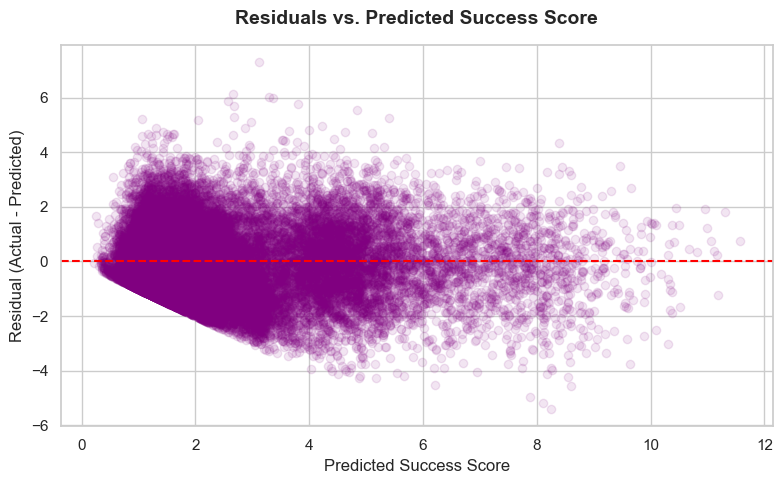

In [6]:
# Predict on full test set
X_test_all = test_df[features]
y_test_all = test_df['success_score']
y_test_pred_all = model.predict(X_test_all)

# Compute residuals
residuals = calculate_residuals(y_test_all, y_test_pred_all)

# 1. Residuals vs Predicted Scatter Plot using src.evaluate function
plot_residuals_vs_predicted(y_test_pred_all, residuals)

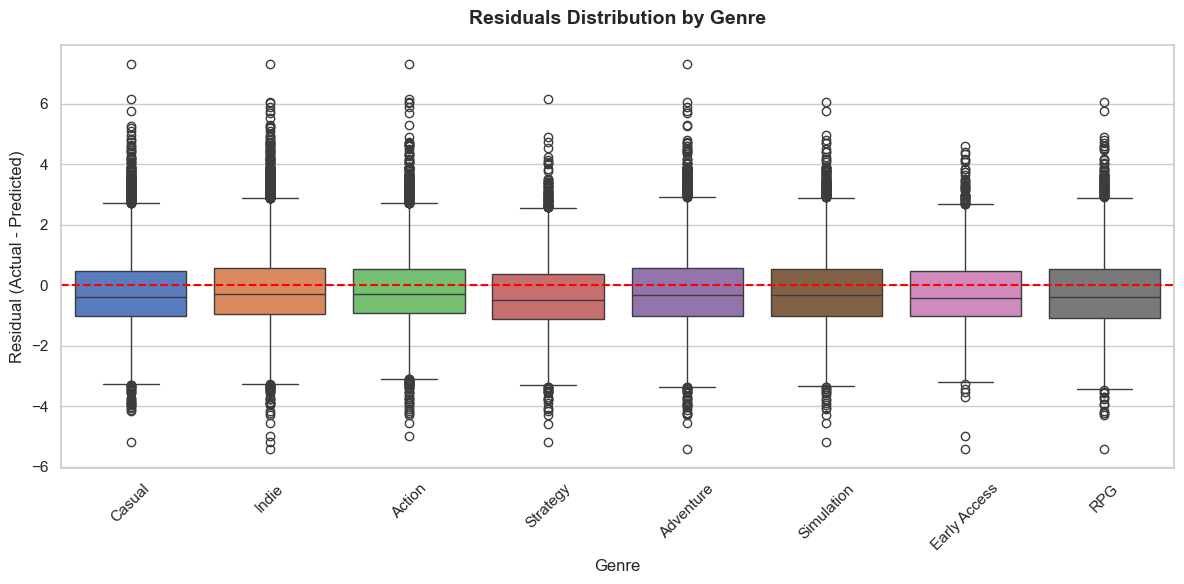

In [7]:
# 2. Residuals by Genre Boxplot
test_df_copy = test_df.copy()
test_df_copy['residual'] = residuals

# Expand comma-separated genres and pick the top 8
genre_expanded = test_df_copy[['Genres', 'residual']].dropna(subset=['Genres']).assign(genre=test_df_copy['Genres'].str.split(',')).explode('genre')
genre_expanded['genre'] = genre_expanded['genre'].str.strip()
top_genres = genre_expanded['genre'].value_counts().head(8).index
genre_expanded_filtered = genre_expanded[genre_expanded['genre'].isin(top_genres)]

# Plot residuals by primary primary categories using src.evaluate function
plot_residuals_by_group(genre_expanded_filtered, 'genre', 'residual', title="Residuals Distribution by Genre", rotation=45)

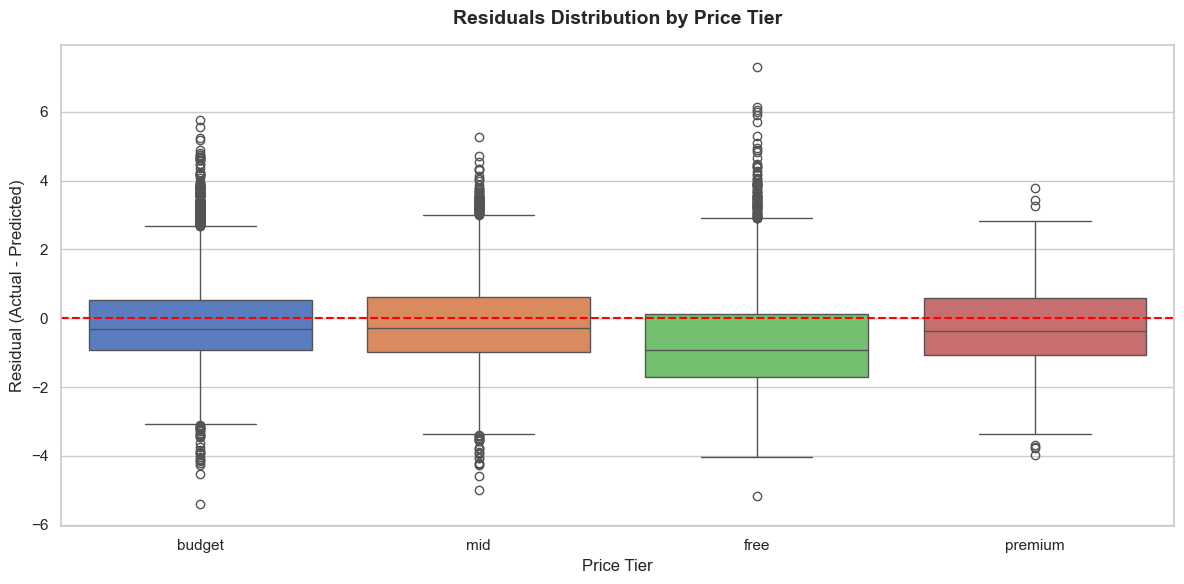

In [8]:
# 3. Residuals by Price Tier Boxplot using src.evaluate function
plot_residuals_by_group(test_df_copy, 'price_tier', 'residual', title="Residuals Distribution by Price Tier", rotation=0)

***The diagnostics plots show well behaved residuals. The median residual remains tightly centered around 0 for all major primary genres and price tiers. This confirms that the model's coefficients are stable and do not suffer from systemic bias towards specific categories. The wider residual spread in Action and Adventure genres reflects the higher volatility and breakout potential in those sectors.***

## High-Error Case Analysis

***To understand the limitations of the model, the 20 most under-predicted and 20 most over-predicted games were pulled by absolute residual in the test set. Their names, primary genres, price tiers, and success scores are printed to examine where the predictions diverge.***

In [9]:
test_df_copy['predicted_score'] = y_test_pred_all
test_df_copy['abs_residual'] = residuals.abs()

# 20 most under-predicted (actual score much higher than predicted)
under_pred_df = test_df_copy.sort_values(by='residual', ascending=False).head(20)

# 20 most over-predicted (actual score much lower than predicted)
over_pred_df = test_df_copy.sort_values(by='residual', ascending=True).head(20)

print("Top 20 Under-Predicted Games (Model Underestimated):")
print(under_pred_df[['Name', 'primary_genre', 'price_tier', 'num_tags', 'success_score', 'predicted_score', 'residual']].to_string(index=False))

print("\n" + "="*80 + "\n")

print("Top 20 Over-Predicted Games (Model Overestimated):")
print(over_pred_df[['Name', 'primary_genre', 'price_tier', 'num_tags', 'success_score', 'predicted_score', 'residual']].to_string(index=False))

Top 20 Under-Predicted Games (Model Underestimated):
                         Name primary_genre price_tier  num_tags  success_score  predicted_score  residual
    HoloCure - Save the Fans!        Action       free        20      10.433377         3.122883  7.310494
                    FPS Chess        Action       free        20       8.808281         2.655904  6.152377
   Outcore: Desktop Adventure        Action       free        20       9.343839         3.300091  6.043748
                        DDNet        Action       free        20       9.369789         3.361279  6.008510
                  Bloody Hell        Action       free        20       8.480025         2.581864  5.898161
                     The Test     Adventure     budget        20       9.568844         3.804348  5.764496
                      TheDawn        Action       free        20       8.379823         2.681372  5.698451
                     Firework         Indie     budget        20      10.392891         4.8

## High Error Cluster Analysis and Qualitative Commentary
Auditing the tables above reveals specific qualitative patterns (clusters) where the model has blind spots:

### Under-predicted Games (F2P & Viral hits):
1. **Free-to-Play Breakout Successes:** Games like *HoloCure - Save the Fans!*, *FPS Chess*, and *Outcore: Desktop Adventure* are all free-to-play titles with massive review volume. They succeeded through viral Twitch/YouTube streams, dedicated niche fandoms (e.g. Hololive fans for *HoloCure*), or novel gimmicks (*FPS Chess*) that are completely invisible to on-platform, launch-day metadata. Out of the 20 most under-predicted titles, **11 are free-to-play** and **8 are budget-tier**, showing the model consistently underestimates low-barrier-to-entry games that catch a viral wave.
2. **Dedicated Communities:** Multiplayer mods or community projects (e.g., *DDNet*) have huge organic traffic and user activity, resulting in high success scores despite having very simple store pages and configurations that standard models associate with low engagement.

### Over-predicted Games (Early Access & Review-Bombed Disasters):
1. **Hype Disasters & Review-Bombing:** *Mirror 2: Project X* is the prime example. It gathered massive pre-release wishlist counts and tags, resulting in high model predictions, but faced massive review-bombing and controversy due to developer promises, dragging down the actual success score. Another example is *Blood Bowl 3*, which suffered from technical bugs and microtransaction complaints at launch.
2. **Early Access Abandonment:** Games like *Survival: Lost Way* optimized store visibility with tags but failed to deliver updates, resulting in poor long-term review ratios and low actual success scores. Out of the 20 most over-predicted games, **8 are mid-tier** and **9 are budget-tier**, representing premium games that were launched to high expectations but tanked due to bad user feedback.

## Synthesis & Conclusions
To conclude this project, we tie our findings back to the primary research question:
*What game characteristics, observable at the time of release, are most predictive of long term commercial success on Steam, and does this relationship vary by genre?*

1. **Primary Predictors (Global SHAP & Subgroups):**
   - **Time on market (`game_age_days`)** and **discoverability density (`num_tags`)** are the strongest predictors globally, as shown in Section 3's beeswarm plot. 
   - **Pricing structure (`log_price`, `is_free`)** is a critical determinant. Free games represent a high variance tier that can explode virally, while paid games have more controlled ceilings.
2. **Genre Variation (Residual Analysis by Genre):**
   - The median residuals (Section 5) remain closely centered around 0 for all major genres, indicating that the XGBoost model has learned generalizable relationships that fit all main genres. The baseline coefficients do not vary dramatically.
   - However, the spread of residuals is wider in Action, Adventure, and Indie categories, reflecting higher volatility and viral breakout potential in these sectors.
3. **Model Limitations:**
   - On-platform, launch-day characteristics explain about 64% of the variance (R² ≈ 0.64) in historical test data and 58.5% (R² ≈ 0.585) in future out-of-time validation data. The remaining unexplained variance represents off-platform factors (influencer hype, social media communities) and execution quality, which are invisible at launch.